In [123]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from tavily import TavilyClient
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_litellm import ChatLiteLLMRouter
from litellm import Router
from dotenv import load_dotenv
import os


In [149]:
load_dotenv()
tavily_client = TavilyClient()

model_list = [
                {
                    "model_name": "model_pool",
                    "litellm_params": {
                        "model": "openrouter/cohere/north-mini-code:free",
                        "api_key": os.getenv("OPEN_ROUTER_API_KEY")
                        },
                        "model_info": {"id": "openrouter/north-mini-code"}
                },
                {
                    "model_name": "model_pool",
                    "litellm_params": {
                        "model": "openrouter/poolside/laguna-s-2.1:free",
                        "api_key": os.getenv("OPEN_ROUTER_API_KEY")
                        },
                        "model_info": {"id": "openrouter/laguna-s-2.1"}
                }
            ]


router = Router(
    model_list=model_list,
    routing_strategy="usage-based-routing-v2",

)

# llm = init_chat_model(model="groq:openai/gpt-oss-20b")

In [150]:
@tool
def web_search(query: str) -> str:
    """Search the web for a query and return the results."""
    
    response = tavily_client.search(
        query=query,
        max_results=3
    )
    formatted_results = []
    for result in response["results"]:
        item = {
            "Title": result.get('title', 'No Title'),
            "URL": result.get('url', ''),
            "Score": result.get('score', 0),
            "Content": result.get('content', '')
        }
        formatted_results.append(item)
    return formatted_results



@tool
def read_file(file_path: str) -> str:
    """Read the content of a file and return it as a string."""
    try:
        with open(file_path, 'r') as file:
            content = file.read()
        return content
    except Exception as e:
        return f"Error reading file: {e}"



@tool
def write_file(file_path: str, content: str) -> str:
    """Write content to a file."""
    try:
        with open(file_path, 'w') as file:
            file.write(content)
        return f"Successfully wrote to {file_path}"
    except Exception as e:
        return f"Error writing to file: {e}"



@tool
def rag_tool(query: str) -> str:

    """Retrieve relevant passages from the user's uploaded documents to answer
    questions about their specific content — facts, data, names, dates,
    numbers, or details that live in those files rather than in general
    knowledge. This is the only way to access document content; you cannot
    see uploaded files directly.

    WHEN TO CALL:
    Call this tool exactly once when the user's question could plausibly be
    answered by their uploaded documents — including questions about people,
    projects, figures, or specifics you would otherwise have to guess at.

    WHEN NOT TO CALL:
    - Greetings, small talk, or conversational filler
    - Math, logic, or calculations (use the calculator tool instead)
    - General knowledge you already know with confidence
    - Follow-up questions about tone, formatting, or phrasing rather than facts
    - Any question already answered earlier in this conversation

    CALL LIMIT — READ CAREFULLY:
    Call this tool at most once per user question. If the result indicates no
    relevant documents were found, that is a final result, not a signal to
    retry. Do not call this tool again with a rephrased, broadened, or
    alternate query in the same turn. Instead, immediately answer using your
    own general knowledge and clearly tell the user their documents did not
    contain the relevant information. Repeated calls for the same question
    waste time and essentially never surface something a well-formed first
    query missed.

    Args:
        query: A precise, standalone search query capturing exactly what the
            user wants to find — not the user's raw message. Resolve pronouns
            and vague references into concrete terms (e.g. "what about its
            pricing?" becomes "product pricing details"). Keep it focused on
            one specific piece of information; do not bundle multiple
            unrelated questions into one query.

    Returns:
        The most relevant retrieved passages with source attribution, or an
        explicit message stating no relevant documents were found — treat the
        latter as final, not as a prompt to try again.
    """


    doc = _load_and_split()

    get_vector_store = Chroma.from_documents(doc, collection_name="new", embedding=_get_embeddings())
    retriver = get_vector_store.as_retriever(search_kwargs={"k": 3}, search_type="mmr")

    get_final = retriver.invoke(query)
    contents = []
    for i in range(len(get_final)):
        contents.append(get_final[i].page_content)

    return contents

In [171]:
# llm = ChatLiteLLMRouter(router=router, model_name="model_pool")
llm = init_chat_model("groq:qwen/qwen3.8-27b")


tools_available = [write_file, read_file, web_search, rag_tool]
agent = create_agent(llm, tools=tools_available, checkpointer=InMemorySaver())

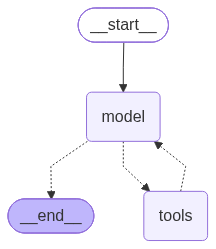

In [169]:
agent

In [153]:
from langchain_community.document_loaders import (
    PyPDFLoader,
    Docx2txtLoader,
    TextLoader,
)
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings, embeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
_embeddings_instance = None
_vectorstore_cache = {}

def _get_embeddings() -> HuggingFaceEmbeddings:
    global _embeddings_instance
    if _embeddings_instance is None:
        
        _embeddings_instance = HuggingFaceEmbeddings(
            model_name=EMBED_MODEL,
            model_kwargs={"device": "cpu"},
            encode_kwargs={"normalize_embeddings": True, "batch_size": 32},
        )
    return _embeddings_instance


def _get_vectorstore(collection_name: str = "file_embeddings") -> Chroma:
    if collection_name not in _vectorstore_cache:
        VECTORSTORE_DIR = os.path.join(
        os.path.dirname(os.path.abspath(__file__)),
        "vectorstore"
        )

        _vectorstore_cache[collection_name] = Chroma(
            persist_directory=VECTORSTORE_DIR,
            embedding_function=_get_embeddings(),
            collection_name=collection_name,
            )
        
    return _vectorstore_cache[collection_name]



def _load_and_split(file_paths: list[str]):
    all_docs = []
    for file in file_paths:
        ext = file.split(".")[-1].lower()
        if ext == "pdf":
            docs = PyPDFLoader(file).load()
        elif ext == "docx":
            docs = Docx2txtLoader(file).load()
        elif ext in ("txt", "md"):
            docs = TextLoader(file, encoding="utf-8").load()
        else:
            raise ValueError(f"Unsupported file type: {ext}. Supported types: pdf, docx, txt, md")

        if not any((d.page_content or "").strip() for d in docs):
            raise ValueError(
                f"No readable text found in '{os.path.basename(file)}' — "
                "it may be a scanned/image-only document."
            )
        all_docs.extend(docs)

    total_chars = sum(len(d.page_content or "") for d in all_docs)

    # Scale chunk size with document length
    if total_chars < 3000:
        chunk_size, chunk_overlap = 400, 80     # short doc — smaller, precise chunks
    elif total_chars < 20000:
        chunk_size, chunk_overlap = 800, 150    # your current default
    else:
        chunk_size, chunk_overlap = 1200, 300   # long doc — bigger chunks, fewer total

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n\n", "\n\n", "\n", "  ", " ", ""],
    )
    return splitter.split_documents(all_docs)


In [178]:
query = r"""it is in pdf folder"""


response = agent.invoke({
    "messages": [
        {
            "role": "user",
             "content": query
        }
    ]
},{"configurable": {"thread_id": "thread-1"}})

In [179]:
print(response['messages'][-1].content)


Here's what's inside `pdf/leetcode.py`:

```python
# Summary of Cadet.docx
"""
This document provides an overview of the Cadet College admission examination pattern, emphasizing the need for clear understanding and ample practice for prospective students. It outlines the typical question types, recommended preparation strategies, and highlights the importance of consistent mock testing.

Key points:
- Detailed explanation of the exam syllabus and question distribution.
- Guidance for parents to help their children develop a solid conceptual foundation.
- Emphasis on regular practice through model tests to build confidence.
- Includes a 2027 Cadet College Admission Model Test prepared by Omlan Bhaia, aimed at students preparing for the upcoming admission cycle.

The material serves as both an informational guide and a practice resource for candidates aspiring to join Cadet Colleges.
"""
```

Interestingly, despite being named `leetcode.py`, it doesn't contain any code — it's just a docs

In [166]:
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState

class AnswerVerification(BaseModel):
    addresses_question: bool = Field(
        description="Whether the AI's answer actually addresses the user's question"
    )
    reasoning: str = Field(
        description="Brief explanation of why the answer does or doesn't address the question"
    )

verifier_llm = llm.with_structured_output(AnswerVerification)

def verify_answer_node(state: MessagesState):
    messages = state["messages"]

    # Find the last human question and the AI's reply to it
    user_question = next(
        m.content for m in reversed(messages) if m.type == "human"
    )
    ai_answer = messages[-1].content

    verification = verifier_llm.invoke([
        {
            "role": "system",
            "content": (
                "You judge whether an AI's answer actually addresses the "
                "user's question. Be strict — a partial, evasive, or "
                "off-topic answer should be marked as not addressing it."
            )
        },
        {
            "role": "user",
            "content": f"Question: {user_question}\n\nAnswer: {ai_answer}"
        }
    ])

    if not verification.addresses_question:
        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": (
                        "I'm not sure that fully answered your question — "
                        "could you rephrase or add more detail on what "
                        "you're looking for?"
                    )
                }
            ]
        }

    # Answer passed verification — no changes needed
    return {}
# Your existing tools
tools = [read_file, web_search, rag_tool]

agent = create_agent(
    model=llm,              # e.g. your ChatLiteLLMRouter instance
    tools=tools,

)


from typing import Literal
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 1. Define the routing function
def check_rag_usage(state: MessagesState) -> Literal["verify_answer", END]:
    """Inspects the message history to see if the RAG tool was called."""
    # Look back through messages generated during the agent node's execution
    for message in reversed(state["messages"]):
        if isinstance(message, ToolMessage) and message.name == "rag_tool":
            # RAG tool was used -> proceed to verification
            return "verify_answer"
            
    # RAG tool was not used -> bypass verification and exit
    return END

# 2. Build the graph
graph = StateGraph(MessagesState)
graph.add_node("agent", agent)
graph.add_node("verify_answer", verify_answer_node)

# Normal initialization edge
graph.add_edge(START, "agent")

# Add the conditional edge after the agent node finishes
graph.add_conditional_edges(
    "agent",
    check_rag_usage,
    {
        "verify_answer": "verify_answer",
        END: END
    }
)

# Normal transition edge from verification to the end
graph.add_edge("verify_answer", END)

app = graph.compile(checkpointer=InMemorySaver())


# result = await app.ainvoke(
#     {"messages": [{"role": "user", "content": "what is ai"}]},
#     config={"configurable": {"thread_id": "thread-1"}}
# )

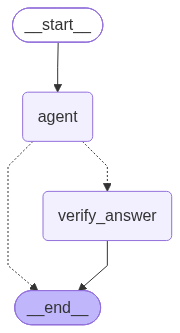

In [167]:
app

In [ ]:
import os

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from groq import RateLimitError, APIError, APIConnectionError
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from functools import partial
from prompts import system_prompt
from tools import calculator, rag_tool, web_search
from llm_router import invoke_with_fallback, MODEL_CHAIN
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from chat_app_backend_rag import llm_structured
from datetime import datetime, timedelta, timezone

import pytz

# Set the timezone to Bangladesh
bd_timezone = pytz.timezone('Asia/Dhaka')

# Get the current time in that timezone
current_date = datetime.now(bd_timezone).strftime("%B %d, %Y")  # e.g. "March 15, 2023"


load_dotenv()

tools = [rag_tool, calculator, web_search]

# Plain (non-tool-bound) model used for cheap one-off calls like title generation.
llm = MODEL_CHAIN[0]
MAX_RETRIES = 1

os.environ["USE_TF"] = "0"

def get_summary_for_chatHead(user: str) -> str:
    prompt = f"""Generate a short, descriptive title for this conversation based on the user's message below.
    Rules:
    - Maximum 5 words
    - No quotation marks, punctuation, or trailing periods
    - Capture the core topic or intent, not a generic summary
    - Do not include phrases like "Chat about" or "Conversation on"
    - Return ONLY the title text, nothing else
    User's message:{user}"""

    response = llm.invoke(prompt)
    return response.content


class AnswerCheck(BaseModel):
    is_relevant: bool = Field(description="True if the answer actually addresses the user's question")
    reason: str = Field(description="Brief explanation of the judgment")


class MessageState(TypedDict):
    message: Annotated[list[BaseMessage], add_messages]
    kb_id: str
    retry_count: int
    rag_call_count: int


def _check_answer(question: str, answer: str) -> AnswerCheck:
    check_prompt = PromptTemplate(
        template="""
            You are checking whether an AI-generated answer actually addresses the user's question.

            Question: {question}
            Answer: {answer}

            Judge whether the answer is relevant and actually responds to the question.
            Be strict but fair.
            Respond with a JSON object matching this schema: {{"is_relevant": true, "reason": "..."}}
        """,
        input_variables=['question', 'answer']
    )
    prompt = check_prompt.format(question=question, answer=answer)
    checker_llm = llm_structured.with_structured_output(AnswerCheck)
    return checker_llm.invoke(prompt)


def check_answer_node(state: MessageState):
    message = list(state['message'])
    last_ai = message[-1]
    last_human = next(m for m in reversed(message) if isinstance(m, HumanMessage))
    retry_count = state.get('retry_count', 0)

    try:
        check = _check_answer(last_human.content, last_ai.content)
    except Exception:
        return {'message': [], 'retry_count': 0}  # fail open, don't loop

    if check.is_relevant:
        return {'message': [], 'retry_count': 0}

    if retry_count >= MAX_RETRIES:
        return {
            'message': [AIMessage(
                id=last_ai.id,
                content="I wasn't able to generate a reliable answer to that. "
                        "Could you try rephrasing your question?"
            )],
            'retry_count': 0
        }
    return {
        'message': [HumanMessage(
            content=f"Your previous answer didn't address the question "
                    f"(reason: {check.reason}). Please answer this again: {last_human.content}"
        )],
        'retry_count': retry_count + 1
    }


def route_after_check(state: MessageState) -> str:
    last = state['message'][-1] if state['message'] else None
    return "retry" if isinstance(last, HumanMessage) else "end"


def chat_message(state: MessageState):
    # Copy instead of mutating the reducer-owned list from state directly.
    message = list(state['message'])
    if not any(isinstance(m, SystemMessage) for m in message):
        message = [system_prompt(current_date)] + message

    try:
        response = invoke_with_fallback(message, tools=tools)
    except RateLimitError:
        response = AIMessage(
            content="I've hit rate limits on all available models right now. "
                    "Please wait a moment and try again."
        )
    except APIConnectionError:
        response = AIMessage(content="I'm having trouble connecting to the model service right now. Please check your connection and try again.")
    except APIError as e:
        response = AIMessage(content=f"Something went wrong while generating a response: {e}")
    except Exception as e:
        response = AIMessage(content=f"An unexpected error occurred: {e}")

    return {'message': [response]}


graph = StateGraph(MessageState)
graph.add_node('chat_message', chat_message)
graph.add_node('tools', ToolNode(tools, messages_key="message"))
# graph.add_node('check_answer', check_answer_node)

graph.add_edge(START, 'chat_message')
graph.add_conditional_edges(
    "chat_message",
    partial(tools_condition, messages_key="message"),
    {"tools": "tools", "__end__": END},
)
graph.add_edge('tools', 'chat_message')


checkpointer = InMemorySaver()
chat = graph.compile(checkpointer=checkpointer)



# from IPython.display import Image, display
# app = graph.compile()
# app.get_graph().print_ascii()

# print(display(Image(app.get_graph().draw_mermaid_png())))